<a href="https://colab.research.google.com/github/jessica-w-pereira/Allurelle-Skincare-and-Cosmetic-recommendation-System/blob/Anjelica/Wrinkles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.8/914.8 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from ultralytics import YOLO
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set dataset path (replace with your actual path)
dataset_path = "/content/drive/MyDrive/Wrinkles"  # Replace with the actual dataset path

In [ ]:
import os
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO('yolov8m.pt')  # Use a medium-sized model for better accuracy

# Set up the save directory in your Google Drive
save_dir = "/content/drive/MyDrive/Trained_models"
os.makedirs(save_dir, exist_ok=True)

# Train YOLO model with project directory in Google Drive
results = model.train(
    data="/content/drive/MyDrive/Wrinkles/data.yaml",  # Path to your dataset config file
    epochs=50,  # Increase epochs for better convergence
    batch=16,  # Adjust batch size based on GPU memory
    imgsz=640,  # Image size (higher resolution can improve accuracy)
    device='cuda',  # Use GPU for faster training
    optimizer='AdamW',  # Use AdamW optimizer for better performance
    lr0=0.001,  # Initial learning rate
    lrf=0.01,  # Final learning rate (with cosine decay)
    momentum=0.937,  # Momentum for SGD
    weight_decay=0.0005,  # Weight decay for regularization
    warmup_epochs=3,  # Warmup epochs to stabilize training
    project=save_dir,  # Save directly to Google Drive
    name="wrinkle_detection",  # Subdirectory name for this training run
    exist_ok=True,  # Overwrite existing project directory
    patience=10,  # Early stopping if no improvement for 10 epochs
    save_period=5,  # Save checkpoint every 5 epochs
    val=True,  # Enable validation during training
    plots=True,  # Generate training plots
    augment=True  # Enable data augmentation
)

# Save the trained model
model.export(format="onnx")  # Export to ONNX format if needed

Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/Wrinkles/data.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=5, cache=False, device=cuda, workers=8, project=/content/drive/MyDrive/Trained_models, name=wrinkle_detection, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save

train: Scanning /content/drive/MyDrive/Wrinkles/train/labels.cache... 458 images, 0 backgrounds, 0 corrupt: 100%|██████████| 458/458 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/Wrinkles/valid/labels.cache... 130 images, 0 backgrounds, 0 corrupt: 100%|██████████| 130/130 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/Trained_models/wrinkle_detection/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/Trained_models/wrinkle_detection
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        130        343      0.507      0.364      0.387      0.207



50 epochs completed in 0.304 hours.
Optimizer stripped from /content/drive/MyDrive/Trained_models/wrinkle_detection/weights/last.pt, 52.0MB
Optimizer stripped from /content/drive/MyDrive/Trained_models/wrinkle_detection/weights/best.pt, 52.0MB

Validating /content/drive/MyDrive/Trained_models/wrinkle_detection/weights/best.pt...
Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:05<00:00,  1.13s/it]


                   all        130        343      0.494      0.373      0.397      0.216
Speed: 0.5ms preprocess, 31.7ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/drive/MyDrive/Trained_models/wrinkle_detection
Ultralytics 8.3.70 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Trained_models/wrinkle_detection/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 149.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 363.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 228.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46

'/content/drive/MyDrive/Trained_models/wrinkle_detection/weights/best.onnx'


0: 640x384 1 0, 1009.3ms
Speed: 17.3ms preprocess, 1009.3ms inference, 28.6ms postprocess per image at shape (1, 3, 640, 384)


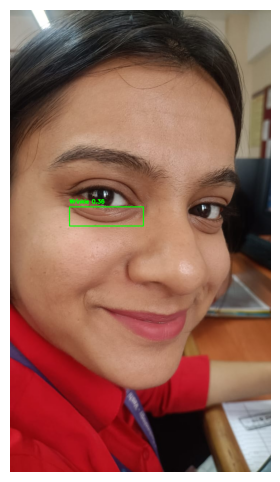

In [ ]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load your trained YOLO model
model = YOLO('/content/drive/MyDrive/Trained_models/wrinkle_detection/weights/best.pt')  # Adjust path to your saved model

def detect_wrinkles(image_path, conf_threshold=0.25):
    """
    Detect wrinkles in an image and display results.
    Args:
        image_path (str): Path to the input image.
        conf_threshold (float): Confidence threshold for detections (0-1).
    """
    # Check if the image file exists
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"The file '{image_path}' does not exist.")

    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read the image from '{image_path}'. Ensure it is a valid image file.")

    # Perform prediction using YOLO model
    results = model(image)  # Use the model directly for inference

    # Accessing results
    for result in results:
        boxes = result.boxes  # List of bounding boxes for each detection

        # Filter by confidence
        for box in boxes:
            confidence = float(box.conf[0])  # Confidence score for the detection
            if confidence >= conf_threshold:
                # Get bounding box coordinates
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Draw bounding box and label
                label = f'Wrinkle {confidence:.2f}'
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green rectangle
                cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)  # Green text

    # Convert BGR to RGB for display in matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

# Example usage:
input_path = '/content/drive/MyDrive/Wrinkles/wrinkle_poorva.jpg'  # Replace with your image path

# Detect and display wrinkles
detect_wrinkles(input_path)

In [ ]:
!pip install pandas matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import os

def mount_drive():
    """Mount Google Drive if not already mounted"""
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

def calculate_yolo_accuracy(gdrive_results_path):
    """
    Calculate accuracy metrics from YOLO results CSV file stored in Google Drive

    Args:
        gdrive_results_path: Full Google Drive path to the results CSV file
    """
    try:
        # Mount Google Drive
        mount_drive()

        # Read the CSV file
        results = pd.read_csv(gdrive_results_path)

        # Print column names to help debug
        print("Available columns in the CSV file:")
        print(results.columns.tolist())

        # Get the final epoch metrics
        final_metrics = results.iloc[-1]

        # Print the first few rows to understand the data structure
        print("\nFirst few rows of the data:")
        print(results.head())

        return results

    except Exception as e:
        print(f"Error reading CSV: {str(e)}")
        return None

def plot_metrics(results_df, metrics_columns):
    """
    Plot specified metrics from the results DataFrame

    Args:
        results_df: Pandas DataFrame containing the results
        metrics_columns: List of column names to plot
    """
    plt.figure(figsize=(12, 6))
    epochs = range(1, len(results_df) + 1)

    for column in metrics_columns:
        if column in results_df.columns:
            plt.plot(epochs, results_df[column], label=column)

    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.title('YOLO Model Training Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
gdrive_path = '/content/drive/MyDrive/Trained_models/wrinkle_detection/results.csv'  # Replace with your path
results = calculate_yolo_accuracy(gdrive_path)

if results is not None:
    print("\nTo plot specific metrics, use the column names from above.")
    print("Example usage:")
    print("plot_metrics(results, ['column1', 'column2'])")

Available columns in the CSV file:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

First few rows of the data:
   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   27.5884         1.73456         2.30501         1.94451   
1      2   51.4592         1.75988         1.95659         1.96764   
2      3   72.7639         1.70327         1.85886         1.90798   
3      4   93.4083         1.64194         1.85741         1.94489   
4      5  114.6060         1.64645         1.86437         1.86152   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.31106            0.12536           0.08388   
1               0.29934            0.14286           0.09765   
2               0.00537            0.20408           0.00275   
3               0.116


Final Model Accuracy Metrics:
Precision: 50.68%
Recall: 36.44%
mAP50: 38.75%
mAP50-95: 20.66%


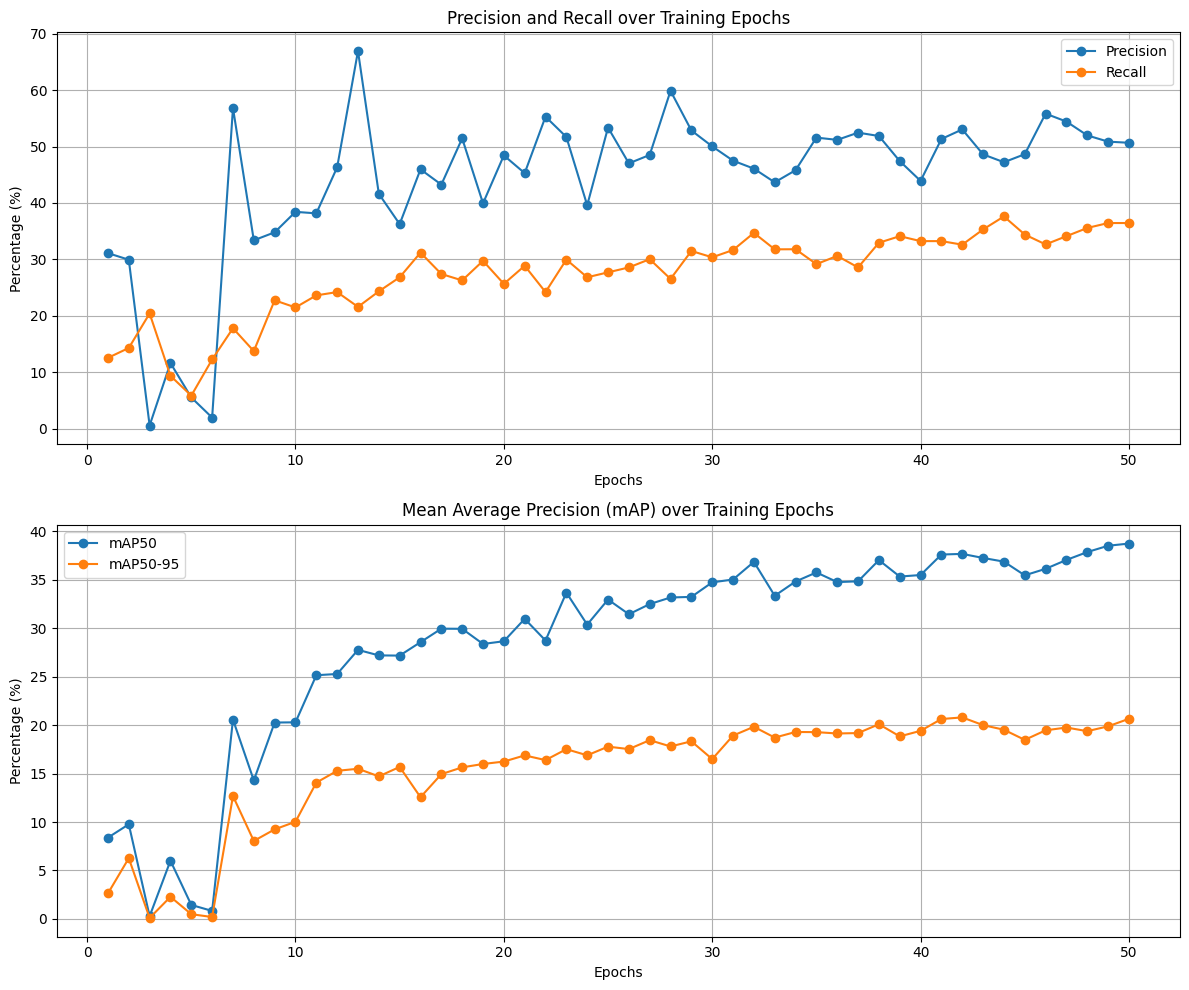

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_yolo_accuracy(results_df):
    """Analyze and visualize YOLO training accuracy metrics"""
    # Get the final epoch metrics
    final_metrics = results_df.iloc[-1]

    # Calculate final accuracy metrics (convert to percentages)
    final_accuracy = {
        'Precision': final_metrics['metrics/precision(B)'] * 100,
        'Recall': final_metrics['metrics/recall(B)'] * 100,
        'mAP50': final_metrics['metrics/mAP50(B)'] * 100,
        'mAP50-95': final_metrics['metrics/mAP50-95(B)'] * 100
    }

    # Create two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Plot accuracy metrics
    epochs = range(1, len(results_df) + 1)
    ax1.plot(epochs, results_df['metrics/precision(B)'] * 100, label='Precision', marker='o')
    ax1.plot(epochs, results_df['metrics/recall(B)'] * 100, label='Recall', marker='o')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_title('Precision and Recall over Training Epochs')
    ax1.grid(True)
    ax1.legend()

    # Plot mAP metrics
    ax2.plot(epochs, results_df['metrics/mAP50(B)'] * 100, label='mAP50', marker='o')
    ax2.plot(epochs, results_df['metrics/mAP50-95(B)'] * 100, label='mAP50-95', marker='o')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Percentage (%)')
    ax2.set_title('Mean Average Precision (mAP) over Training Epochs')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    return final_accuracy, plt.gcf()

# Convert your data to DataFrame
data = pd.read_csv('/content/drive/MyDrive/Trained_models/wrinkle_detection/results.csv')  # Replace with your path

# Analyze results
final_metrics, plot = analyze_yolo_accuracy(data)

# Print final metrics
print("\nFinal Model Accuracy Metrics:")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.2f}%")

# Show plot
plt.show()